# Block-Wise Shrinkage GMRF: Parameter Estimation Demo

This notebook implements the **Parameter Estimation phase** of a custom hierarchical reconciliation algorithm (Block-Wise Shrinkage GMRF).

## Objectives
1.  **Generate Data**: Create a larger strict hierarchy (Country -> Region -> State) with 25 series.
2.  **Base Forecasts**: Use AutoARIMA to obtain residuals.
3.  **Phase 1: Hierarchy Decomposition**: Identify Parent-Children families.
4.  **Phase 2: Local Robust Estimation**: Apply Ledoit-Wolf shrinkage to each family block.
5.  **Phase 3: GMRF Parameter Extraction**: Sparsify the graph by extracting $\phi$ and $\sigma^2$ parameters.
6.  **Verification**: Visualize $\phi$ vs Sample Correlations.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.covariance import LedoitWolf
from numpy.linalg import inv

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from hierarchicalforecast.utils import aggregate

## 1. Synthetic Data Generation (Expanded Hierarchy)

Structure: **Country (1) -> Region (4) -> State (5 per Region)** = 25 Total Series.

In [85]:
# Configuration
n_periods = 300
freq = 'D'
start_date = '2023-01-01'
seed = 42

np.random.seed(seed)
dates = pd.date_range(start=start_date, periods=n_periods, freq=freq)

# --- Define Expanded Strict Hierarchy ---
regions = ['RegionA', 'RegionB', 'RegionC', 'RegionD']
states_per_region = 3

data_rows = []

# Helper to generate random series
def generate_series(n, start_val=100, drift=0.5, noise_level=1):
    return np.cumsum(np.random.normal(drift, noise_level, n)) + start_val

# Generate Bottom Level (State) Data
for region in regions:
    for i in range(1, states_per_region + 1):
        state_name = f"{region}_State{i}"
        values = generate_series(n_periods)
        
        for d, val in zip(dates, values):
            data_rows.append({
                'Country': 'Total',
                'Region': region,
                'State': state_name,
                'ds': d,
                'y': val
            })

flat_df = pd.DataFrame(data_rows)

# Aggregate
spec = [
    ['Country'],
    ['Country', 'Region'],
    ['Country', 'Region', 'State']
]

Y_df, S_df, tags = aggregate(flat_df, spec)
# Note: S_df usually comes with 'unique_id' column from aggregate, avoiding reset_index issues seen before.

print(f"Total series: {len(Y_df['unique_id'].unique())}")
display(S_df.head())

Total series: 17


,unique_id,Total/RegionA/RegionA_State1,Total/RegionA/RegionA_State2,Total/RegionA/RegionA_State3,Total/RegionB/RegionB_State1,Total/RegionB/RegionB_State2,Total/RegionB/RegionB_State3,Total/RegionC/RegionC_State1,Total/RegionC/RegionC_State2,Total/RegionC/RegionC_State3,Total/RegionD/RegionD_State1,Total/RegionD/RegionD_State2,Total/RegionD/RegionD_State3
0,Total,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,Total/RegionA,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Total/RegionB,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Total/RegionC,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
4,Total/RegionD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


## 2. Base Forecasts & Residuals Calculation

In [86]:
# Forecast
Y_train_df = Y_df  # Use full data for this param estimation demo (or split if strictly needed)
# Ensure strictly the required columns to avoid errors
Y_train_df = Y_train_df[['unique_id', 'ds', 'y']]

fcst = StatsForecast(
    models=[AutoARIMA(season_length=7)],
    freq=freq, n_jobs=-1
)

# Fit and get in-sample residuals
# To get residuals for the training set, we use fit_predict or cross_validation, 
# or simply fit and then subtract fitted from actuals.
# Here we'll use forecast_fitted_values after a mock forecast call or just accessing the object properties if available.
# StatsForecast pattern for residuals: fit -> predict_in_sample or similar.
# For simplicity: forecast(fitted=True) on the whole dataset (h=0 effectively for fit, but we need structure)
# We will forecast 1 step just to trigger the fitted values computation easily

# We will forecast 1 step just to trigger the fitted values computation easily

fcst.forecast(df=Y_train_df, h=1, fitted=True)
fitted_vals = fcst.forecast_fitted_values()

# Calculate Residuals
residuals_long = fitted_vals.merge(Y_train_df, on=['unique_id', 'ds'], suffixes=('_hat', ''))
residuals_long['resid'] = residuals_long['y'] - residuals_long['AutoARIMA']

# Pivot to Wide Matrix (T x N)
E_df = residuals_long.pivot(index='ds', columns='unique_id', values='resid').dropna()
print("Residuals Matrix Shape:", E_df.shape)
display(E_df.head())

Residuals Matrix Shape: (300, 17)


unique_id,Total,Total/RegionA,Total/RegionA/RegionA_State1,Total/RegionA/RegionA_State2,Total/RegionA/RegionA_State3,Total/RegionB,Total/RegionB/RegionB_State1,Total/RegionB/RegionB_State2,Total/RegionB/RegionB_State3,Total/RegionC,Total/RegionC/RegionC_State1,Total/RegionC/RegionC_State2,Total/RegionC/RegionC_State3,Total/RegionD,Total/RegionD/RegionD_State1,Total/RegionD/RegionD_State2,Total/RegionD/RegionD_State3
ds,,,,,,,,,,,,,,,,,
2023-01-01,1.201756,0.300371,0.100504,0.099190,0.100677,0.301043,0.100270,0.100034,0.100738,0.301546,0.101932,0.100389,0.099225,0.298797,0.100371,0.098139,0.100286
2023-01-02,-4.801099,-1.674530,-0.131036,-0.541392,-1.002103,-1.603369,-0.488924,-0.521012,-0.591549,-0.790574,-0.029508,-0.889531,0.123259,-0.727420,1.075322,-0.809236,-0.990923
2023-01-03,0.974634,2.210668,0.654917,0.766083,0.789669,-0.896596,-0.069140,0.030691,-0.858562,-2.220338,-0.677254,-0.857143,-0.600242,1.795201,1.996612,-0.453997,0.163628
2023-01-04,6.219786,3.435118,1.530258,0.629160,1.275701,1.588936,1.173758,0.451691,-0.043738,-0.913159,-1.482562,1.137955,-0.325217,1.865555,1.008051,1.894988,-1.078750
2023-01-05,0.502401,0.104460,-0.226925,-0.002112,0.333498,-0.159665,0.092330,-0.042747,-0.210548,-1.428824,-1.771987,-1.176891,1.619890,1.886594,0.233650,0.809505,1.047824


## Phase 1: Hierarchy Decomposition (Identify Families)

We identify "Families" where a family consists of a Parent node and its direct Children.

In [87]:
def get_families(S_in):
    # S_in is the summing matrix dataframe. 
    # In hierarchicalforecast, index usually contains all nodes, columns are bottom nodes.
    # However, 'aggregate' output S_df might be different. Let's inspect S_df structure from previous cell.
    # We will assume node names follow 'Parent/Child' naming convention from aggregate.
    
    # Extract all node names from unique_id column
    if 'unique_id' in S_in.columns:
        nodes = S_in['unique_id'].unique()
    else:
        nodes = S_in.index.unique()
        
    families = {}
    
    for node in nodes:
        # Root is 'Total'.
        # Separator is '/'. Children will have 'Parent/' prefix.
        # Logic: 
        # 1. Split node by '/'
        # 2. Reconstruct parent name.
        
        parts = node.split('/')
        if len(parts) == 1:
            # Top level, has no parent in this logic (or parent is None)
            continue
            
        parent = '/'.join(parts[:-1])
        
        if parent not in families:
            families[parent] = []
        families[parent].append(node)
    
    # Formatting as list of dicts
    family_list = [{'parent': k, 'children': v} for k, v in families.items()]
    return family_list

families = get_families(S_df)
print(f"Total Number of Families Found: {len(families)}")
for f in families:
    print(f"Parent: {f['parent']}, Children Count: {len(f['children'])}")

Total Number of Families Found: 5
Parent: Total, Children Count: 4
Parent: Total/RegionA, Children Count: 3
Parent: Total/RegionB, Children Count: 3
Parent: Total/RegionC, Children Count: 3
Parent: Total/RegionD, Children Count: 3


## Phase 2: Local Robust Estimation (The "Shrink" Step)

We calculate the shrunk covariance matrix for each family using Ledoit-Wolf.

In [88]:
local_estimates = {}

for i, family in enumerate(families):
    p = family['parent']
    children = family['children']
    
    # Columns for this family: Parent + Children
    cols = [p] + children
    
    # Extract subset of residuals
    # Ensure columns exist (AutoARIMA might fail for some, though unlikely with synthetic)
    valid_cols = [c for c in cols if c in E_df.columns]
    E_local = E_df[valid_cols]
    
    # Fit LedoitWolf
    lw = LedoitWolf()
    lw.fit(E_local)
    
    local_sigma = lw.covariance_
    shrinkage = lw.shrinkage_
    
    local_estimates[p] = {
        'sigma': local_sigma,
        'nodes': valid_cols,
        'shrinkage': shrinkage
    }
    
    if i == 0:
        print(f"Verification - First Family ({p}) Shrinkage Coefficient: {shrinkage:.6f}")

Verification - First Family (Total) Shrinkage Coefficient: 0.015742


## Phase 3: GMRF Parameter Extraction (The "Sparsify" Step)

We calculate the GMRF parameters $\phi$ and $\sigma^2$ using the inverse of the local covariance (Precision matrix).

In [89]:
gmrf_params = {}
sample_correlations = []
phi_values = []
labels = []

for parent, est in local_estimates.items():
    sigma = est['sigma']
    nodes = est['nodes']
    
    # Invert to get Precision Matrix
    # try:
    #     precision = inv(sigma)
    # except np.linalg.LinAlgError:
    #     print(f"Warning: Matrix inversion failed for {parent}")
    #     continue
    
    # Parent index is usually 0 since we constructed cols = [p] + children
    p_idx = 0
    
    # NEW: Use Covariance Diagonal (Parent)
    sigma_pp = sigma[p_idx, p_idx]
    
    for i, child_node in enumerate(nodes):
        if i == p_idx: continue # Skip parent itself
        
        # NEW LOGIC: Marginal Dependence (Covariance)
        sigma_pi = sigma[p_idx, i]
        sigma_ii = sigma[i, i]
        
        # Phi (Slope): Regression of Child on Parent (Market Share proxy)
        # Formula: Cov(Child, Parent) / Var(Parent)
        phi = sigma_pi / sigma_pp
        
        # Sigma2 (Noise): Residual Variance
        # Formula: Var(Child) - phi^2 * Var(Parent)
        sigma2 = sigma_ii - (phi**2 * sigma_pp)
        
        gmrf_params[child_node] = {
            'parent': parent,
            'phi': phi,
            'sigma2': sigma2
        }
        
        # --- Data for Visualization ---
        # Calculate standard sample correlation between Parent and Child
        # We use the raw residuals E_local for this
        # Correlation matrix of the current block
        corr_matrix = np.corrcoef(E_df[parent], E_df[child_node])
        sample_corr = corr_matrix[0, 1]
        
        sample_correlations.append(sample_corr)
        phi_values.append(phi)
        labels.append(child_node)

print("GMRF Parameters Extracted. Sample (first 3):")
for k, v in list(gmrf_params.items())[:3]:
    print(f"{k}: {v}")

GMRF Parameters Extracted. Sample (first 3):
Total/RegionA: {'parent': 'Total', 'phi': 0.2392228658785467, 'sigma2': 1.9492839896385283}
Total/RegionB: {'parent': 'Total', 'phi': 0.2390675059677267, 'sigma2': 2.2500715609458264}
Total/RegionC: {'parent': 'Total', 'phi': 0.24099078141977032, 'sigma2': 2.014574953496595}


## Visualization (Research Proof)

Comparison: **Standard Correlation vs GMRF $\phi$ Parameter**.
We expect the GMRF $\phi$ values to be related to, but distinct from, raw correlations (often dampened or cleaner due to the conditional independence assumption structure).

In [90]:
import plotly.express as px
import plotly.graph_objects as go

# Create DataFrame for Plotly
plot_df = pd.DataFrame({
    'Sample Correlation': sample_correlations,
    'GMRF Phi': phi_values,
    'Series': labels,
    'Parent': [gmrf_params[l]['parent'] for l in labels]
})

fig = px.scatter(plot_df, x='Sample Correlation', y='GMRF Phi', 
                 color='Parent',
                 title='Research Proof: Standard Correlation vs GMRF Phi Parameter',
                 hover_data=['Series', 'Parent'])

# Add identity line
fig.add_shape(type='line',
    x0=-1, y0=-1, x1=1, y1=1,
    line=dict(color='Red', width=2, dash='dot'),
)

# Add axis lines
fig.add_hline(y=0, line_width=1, line_color='gray', line_dash='dash')
fig.add_vline(x=0, line_width=1, line_color='gray', line_dash='dash')

fig.update_traces(textposition='top center')
fig.update_layout(
    height=600,
    width=900,
    xaxis_title='Standard Sample Correlation',
    yaxis_title='GMRF Phi Parameter'
)

fig.show()

In [91]:
from scipy import sparse

# 1. Create Index Mapping
all_nodes = sorted(list(set(labels) | {f['parent'] for f in gmrf_params.values()} | {'Total'}))
node_to_idx = {node: i for i, node in enumerate(all_nodes)}
n = len(all_nodes)

# 2. Initialize Sparse Matrix (LIL is best for incremental construction)
Q_global = sparse.lil_matrix((n, n))

# 3. Assemble the Matrix
for child, params in gmrf_params.items():
    p_node = params['parent']
    phi = params['phi']
    sigma2 = params['sigma2']
    
    i = node_to_idx[child]
    p = node_to_idx[p_node]
    
    # The GMRF Stamping Rules
    weight = 1.0 / sigma2
    
    Q_global[i, i] += weight
    Q_global[p, p] += weight * (phi**2)
    Q_global[i, p] -= weight * phi
    Q_global[p, i] -= weight * phi

# 4. Add Root Prior (The Anchor)
# The loop above only adds relative constraints. We need to anchor the root.
root_node = 'Total' # Or find node with no parent
root_idx = node_to_idx[root_node]
# Calculate root variance from residuals
root_sigma2 = np.var(E_df[root_node])
Q_global[root_idx, root_idx] += 1.0 / root_sigma2

# Finalize
Q_global = Q_global.tocsr() # Convert to CSR for efficient arithmetic

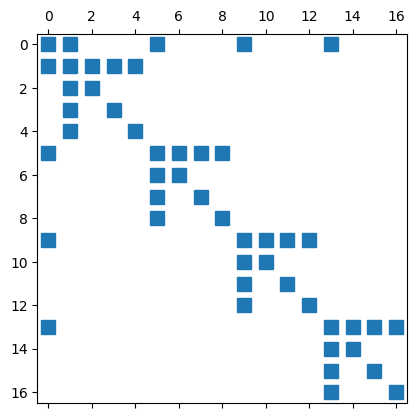

In [92]:
plt.spy(Q_global)

In [93]:
from scipy.sparse.linalg import spsolve

# 1. Create the RHS vector (Precision-weighted Base Forecasts)
# Need to align y_hat with node_to_idx
y_hat_vec = np.array([base_forecasts[node] for node in all_nodes])
rhs = Q_global.dot(y_hat_vec)

# 2. Solve
y_reconciled_vec = spsolve(Q_global, rhs)

NameError: name 'base_forecasts' is not defined